<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
         survived      pclass         age       sibsp       parch        fare
count  891.

C:\Users\tejas\AppData\Local\Temp\ipykernel_24008\902209677.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)


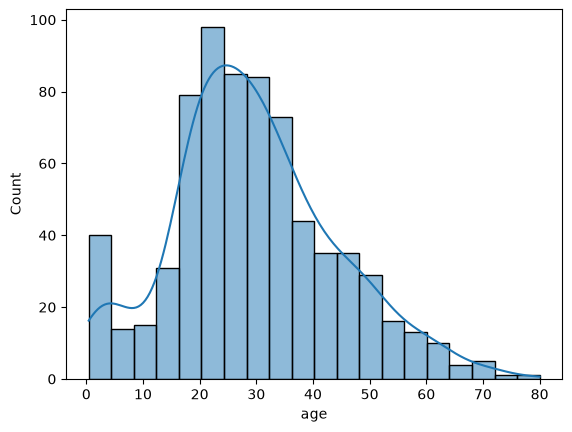

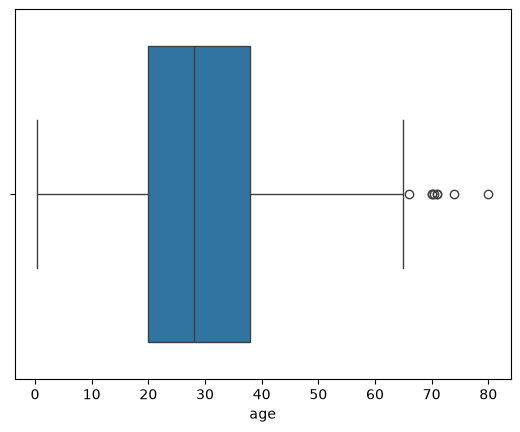

age outliers: 8


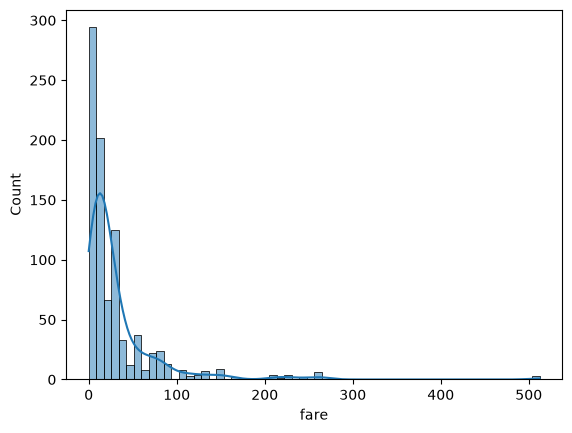

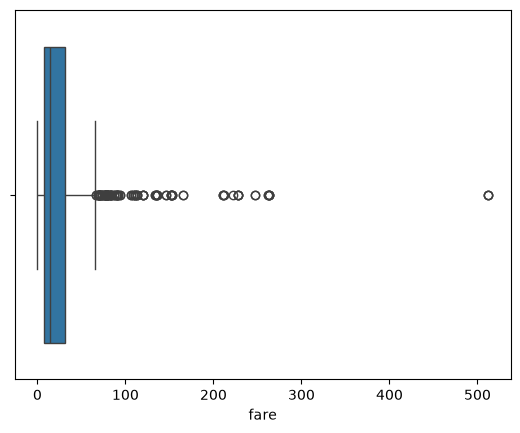

fare outliers: 114
32.09668087739032 14.4542 8.05
right-skewed
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64


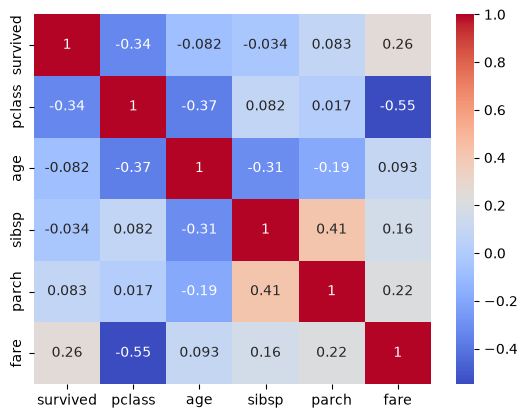

pclass  fare      0.548193
fare    pclass    0.548193
dtype: float64


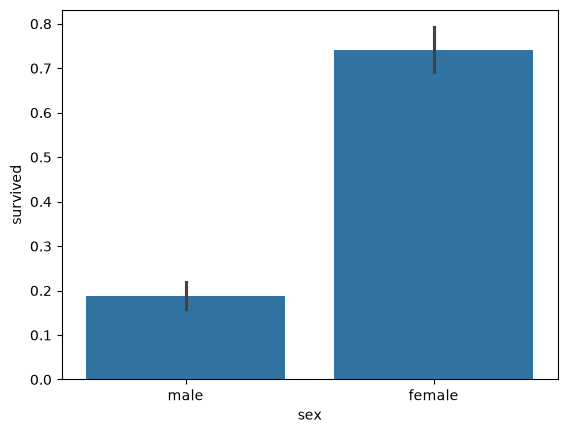

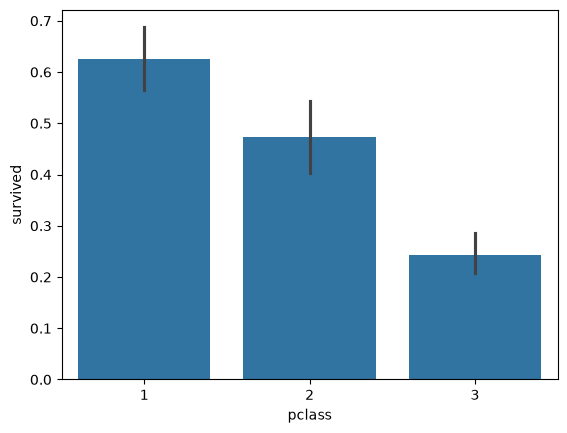

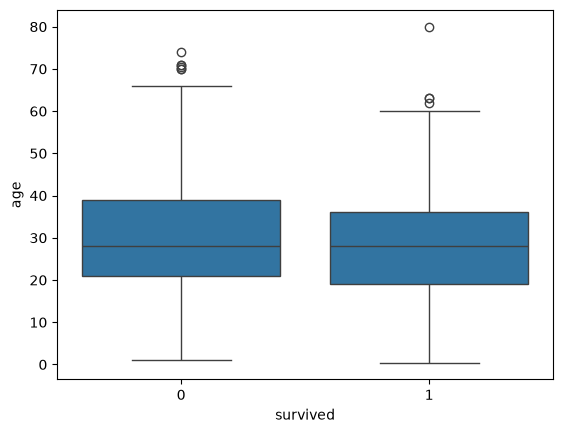

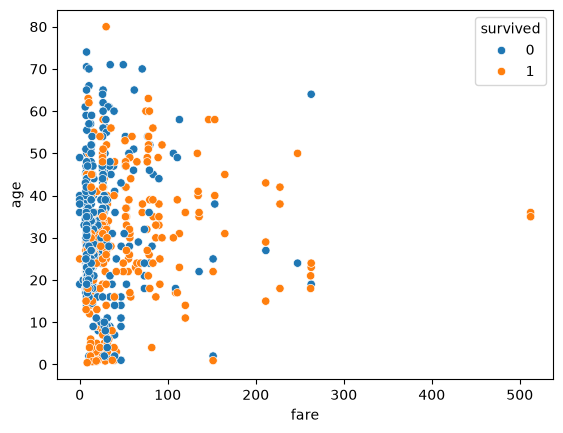

                age          fare
count  7.120000e+02  8.890000e+02
mean   2.943962e-16  1.398706e-16
std    1.000703e+00  1.000563e+00
min   -2.017717e+00 -6.462044e-01
25%   -6.657639e-01 -4.872378e-01
50%   -1.133826e-01 -3.551972e-01
75%    5.770939e-01 -2.207954e-02
max    3.477095e+00  9.668551e+00


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)
print(df.info())
print(df.describe())
print(df.shape)

missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent[missing_percent > 0]
print(missing_percent)

for col, perc in missing_percent.items():
    if perc < 5:
        df = df.dropna(subset=[col])
    elif perc <= 30:
        if df[col].dtype in ["float64","int64"]:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df.drop(columns=[col], inplace=True)

for col in ["age","fare"]:
    sns.histplot(df[col], kde=True)
    plt.show()
    sns.boxplot(x=df[col])
    plt.show()
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col,"outliers:",len(outliers))

fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]
print(fare_mean,fare_median,fare_mode)
if fare_mean > fare_median > fare_mode:
    print("right-skewed")
elif fare_mean < fare_median < fare_mode:
    print("left-skewed")
else:
    print("symmetric")

print(df.groupby("sex")["survived"].mean())
print(df.groupby("pclass")["survived"].mean())
print(df.groupby(["sex","pclass"])["survived"].mean())

corr_cols = ["survived","pclass","age","sibsp","parch","fare"]
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()
corr_pairs = corr_matrix.unstack().dropna()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
top2 = corr_pairs.abs().sort_values(ascending=False).head(2)
print(top2)

sns.barplot(x="sex", y="survived", data=df)
plt.show()
sns.barplot(x="pclass", y="survived", data=df)
plt.show()
sns.boxplot(x="survived", y="age", data=df)
plt.show()
sns.scatterplot(x="fare", y="age", hue="survived", data=df)
plt.show()

scaler = StandardScaler()
df[["age","fare"]] = scaler.fit_transform(df[["age","fare"]])
print(df[["age","fare"]].describe())
